# 马尔可夫链：天气变化示例

本 Notebook 配套文档「01_马尔可夫模型简介.md」，用同一套符号与同一组数值把马尔可夫链的核心计算跑通：一步推进、多步预测、$k$ 步转移矩阵与稳态分布。


## 1. 参数设定：状态、初始分布与转移矩阵

状态集合 $S=\{S_1,S_2\}$，分别表示“晴/雨”。用行向量表示分布：
$$
P(s_t)=[P(s_t=S_1),\,P(s_t=S_2)]
$$


In [72]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ================== 全局环境配置 ==================
# 配置 matplotlib 使用中文字体
# 注意：run_jupyterlab.sh 已通过挂载 matplotlibrc 文件进行全局配置
# 这里再次配置是为了确保在非 Docker 环境（如本地直接运行）下也能正确显示中文
def config_fonts():
    try:
        # 尝试多种常用中文字体，优先使用挂载的字体
        # SimHei: Windows标准/Docker挂载
        # Heiti TC: Mac标准
        fonts = ['SimHei', 'Heiti TC', 'WenQuanYi Micro Hei', 'DejaVu Sans']
        rcParams['font.sans-serif'] = fonts
        rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    except:
        pass

config_fonts()
print("环境配置完成，中文字体已设置。")

state_names = ["晴", "雨"]

A = np.array([[0.7, 0.3], [0.4, 0.6]], dtype=float)
pi = np.array([1.0, 0.0], dtype=float)

A, pi

环境配置完成，中文字体已设置。


(array([[0.7, 0.3],
        [0.4, 0.6]]),
 array([1., 0.]))

## 2. 一步推进：从 $P(s_t)$ 到 $P(s_{t+1})$

分布推进公式：
$$
P(s_{t+1})=P(s_t)\cdot A
$$


In [73]:
p1 = pi @ A
p2 = p1 @ A

p1, p2

(array([0.7, 0.3]), array([0.61, 0.39]))

## 3. $k$ 步转移与多步预测

对任意整数 $k\ge 1$：
$$
P(s_{t+k})=P(s_t)\cdot A^k
$$
并且 $(A^k)_{ij}=P(s_{t+k}=S_j\mid s_t=S_i)$。


In [74]:
def predict_distribution(p0: np.ndarray, A: np.ndarray, k: int) -> np.ndarray:
    Ak = np.linalg.matrix_power(A, k)
    return p0 @ Ak

for k in range(1, 11):
    pk = predict_distribution(pi, A, k)
    print(k, pk)

1 [0.7 0.3]
2 [0.61 0.39]
3 [0.583 0.417]
4 [0.5749 0.4251]
5 [0.57247 0.42753]
6 [0.571741 0.428259]
7 [0.5715223 0.4284777]
8 [0.57145669 0.42854331]
9 [0.57143701 0.42856299]
10 [0.5714311 0.4285689]


### 3.1 可视化：分布随时间的演化

下面把 $P(s_t)$ 的每一维当作一条时间序列，直观看到分布如何被不断“推进”。


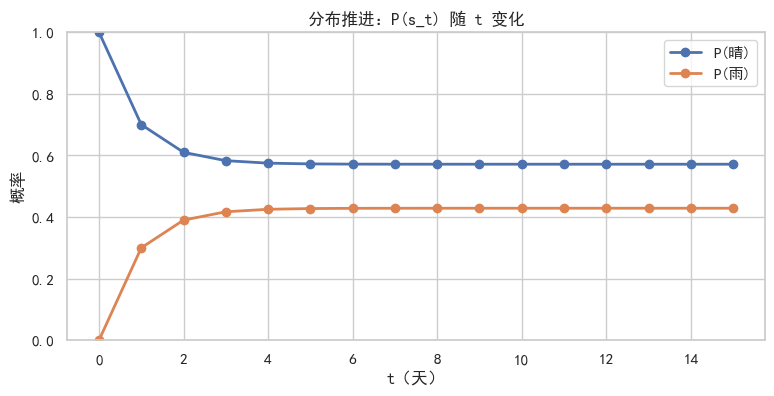

In [75]:
def distribution_trajectory(p0: np.ndarray, A: np.ndarray, steps: int) -> np.ndarray:
    traj = np.empty((steps + 1, A.shape[0]), dtype=float)
    traj[0] = p0
    for t in range(steps):
        traj[t + 1] = traj[t] @ A
    return traj

steps = 15
traj = distribution_trajectory(pi, A, steps)
ts = np.arange(steps + 1)

plt.figure(figsize=(9, 4))
for i, name in enumerate(state_names):
    plt.plot(ts, traj[:, i], marker="o", linewidth=2, label=f"P({name})")
plt.title("分布推进：P(s_t) 随 t 变化")
plt.xlabel("t（天）")
plt.ylabel("概率")
plt.ylim(0.0, 1.0)
plt.legend()
plt.show()

## 4. 稳态分布（平稳分布）

稳态分布 $\mu$ 满足：
$$
\mu = \mu A,\quad \sum_i \mu_i = 1
$$
下面给出两种求法：线性方程法与特征向量法。


In [76]:
def stationary_by_linear_system(A: np.ndarray) -> np.ndarray:
    n = A.shape[0]
    M = (A.T - np.eye(n))
    M[-1, :] = 1.0
    b = np.zeros(n)
    b[-1] = 1.0
    return np.linalg.solve(M, b)

mu_lin = stationary_by_linear_system(A)
mu_lin

array([0.57142857, 0.42857143])

In [77]:
def stationary_by_eigen(A: np.ndarray) -> np.ndarray:
    eigvals, eigvecs = np.linalg.eig(A.T)
    idx = int(np.argmin(np.abs(eigvals - 1.0)))
    v = np.real(eigvecs[:, idx])
    v = v / v.sum()
    return v

mu_eig = stationary_by_eigen(A)
mu_eig

array([0.57142857, 0.42857143])

### 4.1 可视化：多步转移矩阵 $A^k$ 的热力图

热力图可以把“从某个状态出发，$k$ 步之后落到各状态的概率”一眼看清。


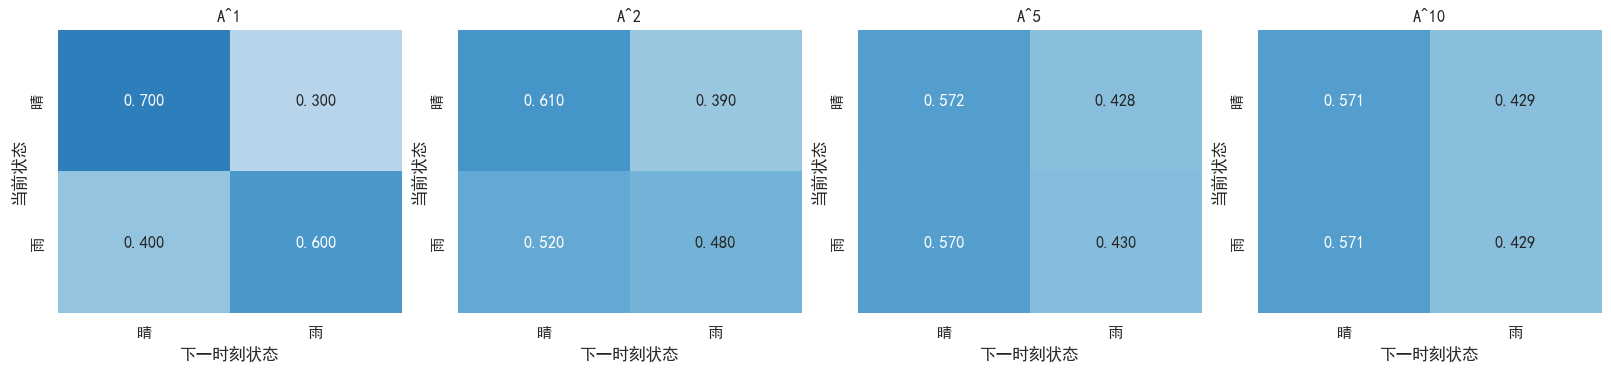

In [78]:
def plot_matrix_heatmap(M: np.ndarray, title: str, ax: plt.Axes) -> None:
    if sns is not None:
        sns.heatmap(
            M,
            ax=ax,
            annot=True,
            fmt=".3f",
            cmap="Blues",
            vmin=0.0,
            vmax=1.0,
            cbar=False,
            xticklabels=state_names,
            yticklabels=state_names,
        )
    else:
        im = ax.imshow(M, cmap="Blues", vmin=0.0, vmax=1.0)
        for (i, j), val in np.ndenumerate(M):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center")
        ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(len(state_names)), labels=state_names)
        ax.set_yticks(range(len(state_names)), labels=state_names)

    ax.set_title(title)
    ax.set_xlabel("下一时刻状态")
    ax.set_ylabel("当前状态")

ks = [1, 2, 5, 10]
fig, axes = plt.subplots(1, len(ks), figsize=(4 * len(ks), 3.6), constrained_layout=True)
for ax, k in zip(axes, ks):
    Ak = np.linalg.matrix_power(A, k)
    plot_matrix_heatmap(Ak, title=f"A^{k}", ax=ax)
plt.show()

### 4.2 可视化：分布到稳态的收敛速度

用 $\lVert P(s_{t})-\mu\rVert_1$（或等价的总变差距离）来量化“还差多远到稳态”。


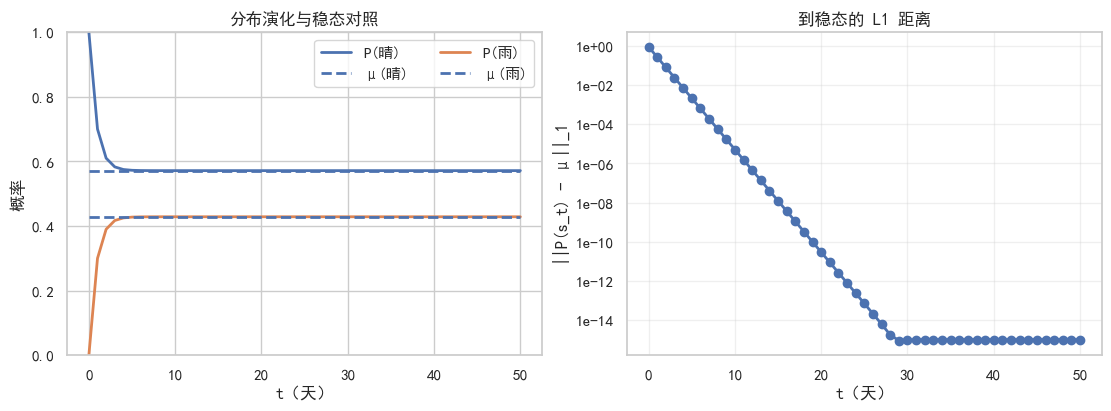

In [79]:
def l1_distance(p: np.ndarray, q: np.ndarray) -> float:
    return float(np.sum(np.abs(p - q)))

steps = 50
traj = distribution_trajectory(pi, A, steps)
dist = np.array([l1_distance(traj[t], mu_lin) for t in range(steps + 1)])

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

ts = np.arange(steps + 1)
for i, name in enumerate(state_names):
    axes[0].plot(ts, traj[:, i], linewidth=2, label=f"P({name})")
    axes[0].hlines(mu_lin[i], xmin=0, xmax=steps, linestyles="--", linewidth=2, label=f"μ({name})")
axes[0].set_title("分布演化与稳态对照")
axes[0].set_xlabel("t（天）")
axes[0].set_ylabel("概率")
axes[0].set_ylim(0.0, 1.0)
axes[0].legend(ncols=2)

axes[1].plot(ts, dist, marker="o", linewidth=2)
axes[1].set_title("到稳态的 L1 距离")
axes[1].set_xlabel("t（天）")
axes[1].set_ylabel("||P(s_t) - μ||_1")

import matplotlib as mpl
from matplotlib.ticker import FuncFormatter, NullFormatter

mpl.rcParams["axes.unicode_minus"] = False

def sci_e_formatter(y: float, _pos: int) -> str:
    if y == 0:
        return "0"
    return f"{y:.0e}"

axes[1].set_yscale("log")
axes[1].yaxis.set_major_formatter(FuncFormatter(sci_e_formatter))
axes[1].yaxis.set_minor_formatter(NullFormatter())
axes[1].grid(True, which="both", alpha=0.3)

plt.show()

In [80]:
mu_lin @ A, mu_eig @ A

(array([0.57142857, 0.42857143]), array([0.57142857, 0.42857143]))

## 5. 经验验证：用随机模拟逼近稳态

用转移矩阵做离散采样，跑一条长链，并用频率估计稳态分布。


In [81]:
rng = np.random.default_rng(0)

def simulate_chain(A: np.ndarray, s0: int, steps: int, rng: np.random.Generator) -> np.ndarray:
    states = np.empty(steps + 1, dtype=int)
    states[0] = s0
    for t in range(steps):
        states[t + 1] = rng.choice(A.shape[0], p=A[states[t]])
    return states

steps = 200000
states = simulate_chain(A, s0=0, steps=steps, rng=rng)
counts = np.bincount(states, minlength=A.shape[0])
freq = counts / counts.sum()

freq, mu_lin

(array([0.57231214, 0.42768786]), array([0.57142857, 0.42857143]))

### 5.1 可视化：经验频率如何逐步逼近稳态

把“截至当前时刻的经验频率”画成曲线，可以观察随机波动与收敛趋势。


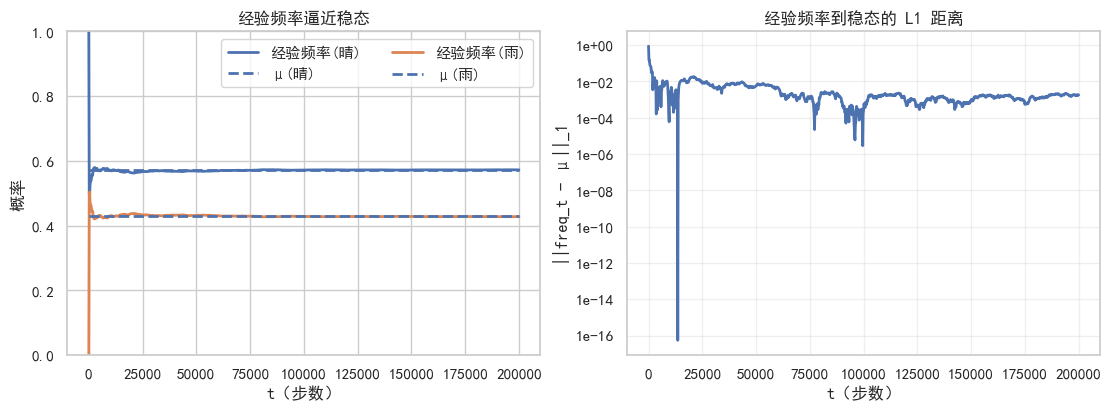

In [82]:
stride = 200
sample_ts = np.arange(0, steps + 1, stride)

cum_counts = np.vstack([np.cumsum(states == i) for i in range(A.shape[0])]).T
freq_running = cum_counts[sample_ts] / (sample_ts.reshape(-1, 1) + 1)
err_running = np.sum(np.abs(freq_running - mu_lin), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

for i, name in enumerate(state_names):
    axes[0].plot(sample_ts, freq_running[:, i], linewidth=2, label=f"经验频率({name})")
    axes[0].hlines(mu_lin[i], xmin=0, xmax=steps, linestyles="--", linewidth=2, label=f"μ({name})")
axes[0].set_title("经验频率逼近稳态")
axes[0].set_xlabel("t（步数）")
axes[0].set_ylabel("概率")
axes[0].set_ylim(0.0, 1.0)
axes[0].legend(ncols=2)

axes[1].plot(sample_ts, err_running, linewidth=2)
axes[1].set_title("经验频率到稳态的 L1 距离")
axes[1].set_xlabel("t（步数）")
axes[1].set_ylabel("||freq_t - μ||_1")

import matplotlib as mpl
from matplotlib.ticker import FuncFormatter, NullFormatter

mpl.rcParams["axes.unicode_minus"] = False

def sci_e_formatter(y: float, _pos: int) -> str:
    if y == 0:
        return "0"
    return f"{y:.0e}"

axes[1].set_yscale("log")
axes[1].yaxis.set_major_formatter(FuncFormatter(sci_e_formatter))
axes[1].yaxis.set_minor_formatter(NullFormatter())
axes[1].grid(True, which="both", alpha=0.3)

plt.show()

## 6. 小练习

1. 把初始分布改成 $\pi=[0.5,0.5]$，对比第 1～10 天的分布序列。
2. 把转移矩阵改成一组你自己设定的概率（每行和为 1），观察稳态分布的变化。
